In [1]:
import torch
import pytorch_lightning as pl

print("Torch Version:", torch.__version__)
print("Lightning Version:", pl.__version__)

Torch Version: 2.12.0+cpu
Lightning Version: 2.6.5


In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\HP\Desktop\retailpulse_project\data\processed\daily_sales.csv')

df.head()

,ds,y
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [3]:
df = df[['ds', 'y']]
df.head()

,ds,y
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [4]:
# sort by date

In [5]:

df['ds'] = pd.to_datetime(df['ds'])

df = df.sort_values('ds')

df.reset_index(drop=True, inplace=True)

In [6]:
print(df.isnull().sum())

ds    0
y     0
dtype: int64


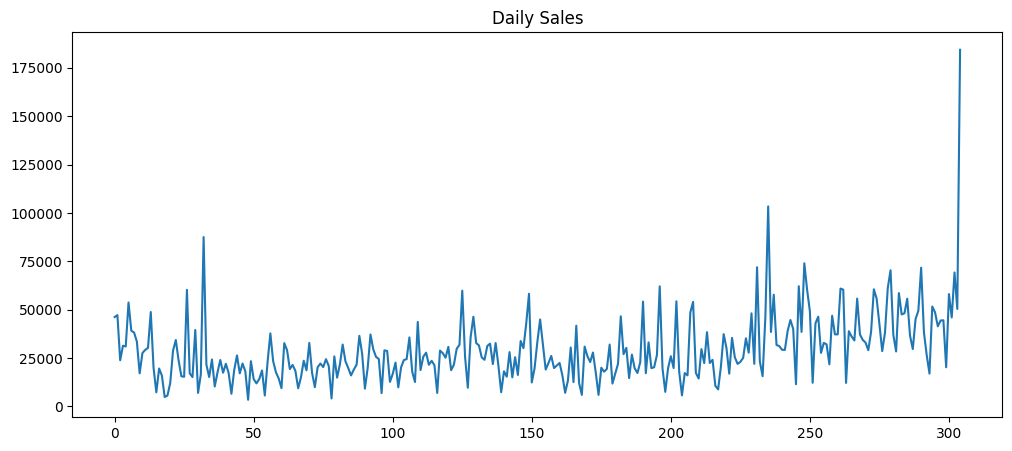

In [7]:
# to plot sales

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['y'])
plt.title("Daily Sales")
plt.show()

In [9]:
# minmax scaler

from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

sales_scaled = scaler.fit_transform(df[['y']])

print(sales_scaled.shape)

(305, 1)


In [10]:
# verify scales


print("Minimum:", sales_scaled.min())
print("Maximum:", sales_scaled.max())

Minimum: 0.0
Maximum: 1.0


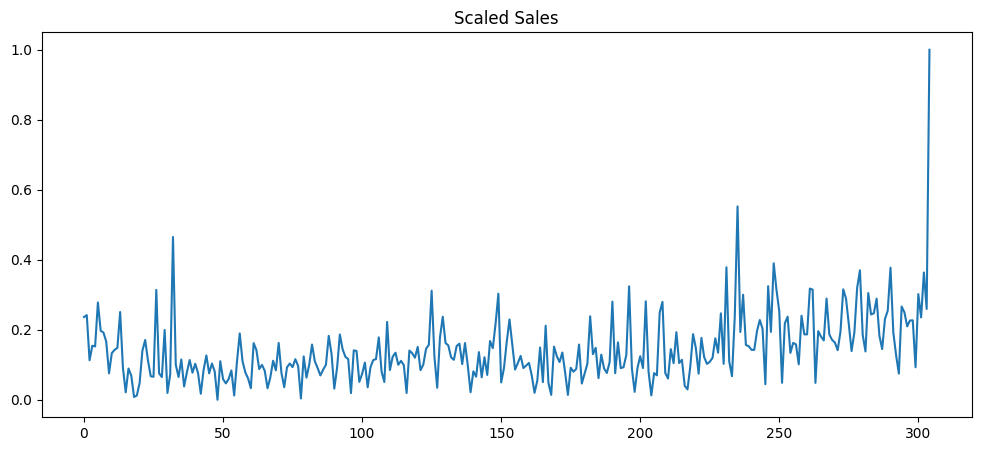

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(sales_scaled)
plt.title("Scaled Sales")
plt.show()

In [12]:
# sequence func

def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

In [14]:
# and to generate sequence func

SEQ_LENGTH = 30

X, y = create_sequences(sales_scaled, SEQ_LENGTH)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (275, 30, 1)
y shape: (275, 1)


In [15]:
print("Input Sequence:")
print(X[0])

print("\nTarget:")
print(y[0])

Input Sequence:
[[0.23634707]
 [0.24190338]
 [0.11298005]
 [0.15435686]
 [0.1524112 ]
 [0.27802141]
 [0.19710615]
 [0.19212915]
 [0.16611594]
 [0.07553033]
 [0.13344392]
 [0.14260303]
 [0.14822158]
 [0.25071702]
 [0.09136321]
 [0.02130179]
 [0.08933269]
 [0.06904467]
 [0.00799851]
 [0.01219028]
 [0.04790447]
 [0.14019438]
 [0.17084483]
 [0.1125442 ]
 [0.06717348]
 [0.06573697]
 [0.31402545]
 [0.0756541 ]
 [0.0647896 ]
 [0.19940313]]

Target:
[0.01955177]


In [17]:
print(X.shape[1])

30


In [19]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (220, 30, 1)
X_test: (55, 30, 1)
y_train: (220, 1)
y_test: (55, 1)


In [21]:
# convert to torch tensors
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(type(X_train))
print(type(y_train))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


C:\Users\HP\AppData\Local\Temp\ipykernel_24680\3739503142.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
C:\Users\HP\AppData\Local\Temp\ipykernel_24680\3739503142.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
C:\Users\HP\AppData\Local\Temp\ipykernel_24680\3739503142.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
C:\Users\HP\AppData\Local\Temp\ipykernel_24680\3739503142

In [22]:
# verify shapes

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([220, 30, 1])
y_train shape: torch.Size([220, 1])
X_test shape: torch.Size([55, 30, 1])
y_test shape: torch.Size([55, 1])


In [23]:
# make lstm model

import torch.nn as nn
import pytorch_lightning as pl

class LSTMForecast(pl.LightningModule):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=50,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(50, 1)

        self.loss_fn = nn.MSELoss()

    def forward(self, x):

        lstm_out, (hidden, cell) = self.lstm(x)

        output = self.fc(hidden[-1])

        return output

    def training_step(self, batch, batch_idx):

        x, y = batch

        y_hat = self(x)

        loss = self.loss_fn(y_hat, y)

        self.log("train_loss", loss)

        return loss

    def configure_optimizers(self):

        return torch.optim.Adam(
            self.parameters(),
            lr=0.001
        )

In [24]:
# instances

model = LSTMForecast()

print(model)

LSTMForecast(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
  (loss_fn): MSELoss()
)


In [25]:
#forward pass test


sample_output = model(X_train[:5])

print(sample_output.shape)

torch.Size([5, 1])


In [26]:
# dataset for tensor

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [27]:
# and loaders 


train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 14
Test batches: 4


In [28]:
# and trainer


trainer = pl.Trainer(
    max_epochs=20,
    accelerator="cpu",
    enable_checkpointing=False,
    logger=False
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [32]:

trainer.fit(model, train_loader)

print("Training Completed!")


  | Name    | Type    | Params | Mode  | FLOPs
----------------------------------------------------
0 | lstm    | LSTM    | 31.0 K | train | 0    
1 | fc      | Linear  | 51     | train | 0    
2 | loss_fn | MSELoss | 0      | train | 0    
----------------------------------------------------
31.1 K    Trainable params
0         Non-trainable params
31.1 K    Total params
0.124     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
0         Total Flops
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` ar

Training Completed!


In [33]:
# evaluation mode
model.eval()

LSTMForecast(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
  (loss_fn): MSELoss()
)

In [34]:
# predictions 


with torch.no_grad():
    predictions = model(X_test)

print(predictions.shape)

torch.Size([55, 1])


In [35]:
# tensor to numpy

predictions = predictions.numpy()
actual = y_test.numpy()

In [36]:
predictions_actual = scaler.inverse_transform(predictions)
actual_sales = scaler.inverse_transform(actual)

In [37]:
# see predictions

import pandas as pd

results = pd.DataFrame({
    "Actual": actual_sales.flatten(),
    "Predicted": predictions_actual.flatten()
})

results.head(10)

,Actual,Predicted
0,49089.468750,27677.310547
1,12215.509766,27809.253906
2,42962.796875,27320.867188
3,46401.140625,27136.605469
4,27655.199219,27108.777344
5,32850.250000,26882.792969
6,32071.619141,26709.578125
7,21767.939453,26566.119141
8,46868.648438,26314.507812
9,37248.160156,26419.884766


In [38]:
# modules 

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

In [39]:
# cal mae

mae = mean_absolute_error(
    actual_sales,
    predictions_actual
)

print("MAE:", mae)

MAE: 19650.236328125


In [41]:
# ca; rmse

rmse = np.sqrt(
    mean_squared_error(
        actual_sales,
        predictions_actual
    )
)

print("RMSE:", rmse)

RMSE: 29353.82823415031


In [43]:
# cal mapw


mape = np.mean(
    np.abs(
        (actual_sales - predictions_actual)
        / actual_sales
    )
) * 100

print("MAPE:", round(mape, 2), "%")

MAPE: 39.89 %


In [44]:
# interpretation

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 19650.24
RMSE : 29353.83
MAPE : 39.89%


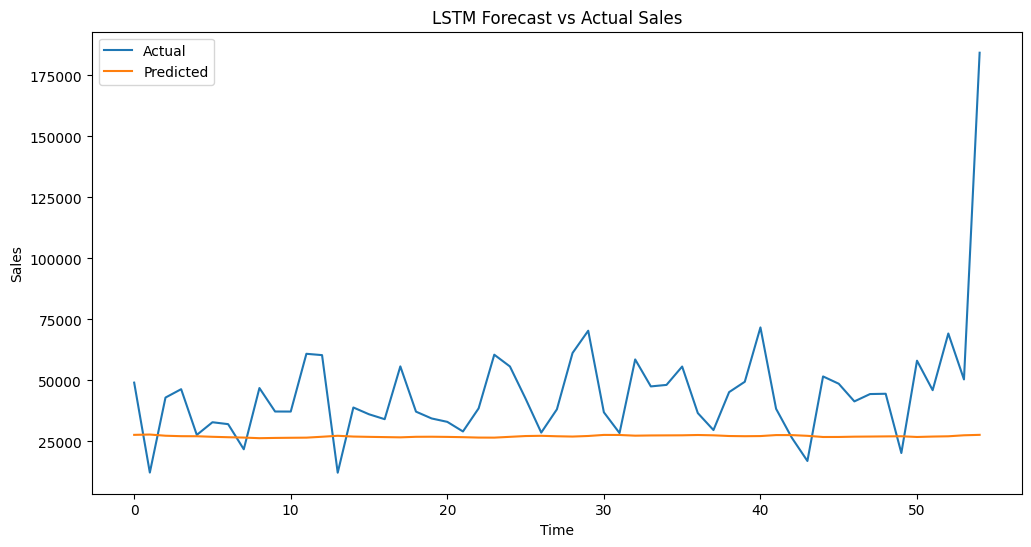

In [45]:
# all the in visuals

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(actual_sales, label="Actual")
plt.plot(predictions_actual, label="Predicted")

plt.title("LSTM Forecast vs Actual Sales")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [47]:
torch.save(model.state_dict(),
           r"C:\Users\HP\Desktop\retailpulse_project\models\lstm_forecast_model.pth")